# 06-Transformers II: Architecture

In Lesson 05, we engineered the absolute core of the AI revolution: **Self-Attention**. We proved that by using Queries, Keys, and Values, a sentence can mathematically contextualize itself in parallel.

However, a single Self-Attention mechanism has two catastrophic flaws:

1. **It has zero concept of time or order.** To a pure Self-Attention matrix, *"The dog bit the man"* is mathematically identical to *"The man bit the dog"*. It treats a sentence like a scrambled bag of words.
2. **It only has one perspective.** A single attention head might focus on noun-adjective relationships. But what about subject-verb relationships? Or pronoun resolutions?

To build a true **Transformer**, we must inject the physics of time back into the vectors, and expand the network's perspective.

Let's set up our PyTorch environment to build a complete Transformer Encoder Block.

In [1]:
import torch
import torch.nn as nn
import math
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set professional visualization styling
sns.set_theme(style="whitegrid")

print("✅ PyTorch Transformer Architecture Environment Ready.")

✅ PyTorch Transformer Architecture Environment Ready.


# 1. Multi-Head Attention (The Committee of Experts)

If you have a 512-dimensional embedding ($d_{model} = 512$), running a single massive Attention operation is highly inefficient. The network tends to average out all the nuanced semantics into one blurry context vector.

Instead, the Transformer implements **Multi-Head Attention (MHA)**.
It mathematically slices the 512-dimensional embedding into $H$ smaller chunks (e.g., $H=8$ heads, each with exactly 64 dimensions).

1. Each of the 8 heads performs its own completely independent Scaled Dot-Product Attention in parallel.
* **Head 1** might learn to look for grammatical subjects.
* **Head 2** might learn to look for emotional sentiment.
* **Head 3** might learn to resolve pronouns (e.g., figuring out who "he" refers to).


2. Once all 8 heads finish calculating their 64-dimensional context vectors, we **concatenate** them back together into a single 512-dimensional vector.
3. We pass this concatenated vector through a final linear projection matrix ($W^O$) to fuse the 8 perspectives together.

$$\text{MultiHead}(Q, K, V) = \text{Concat}(\text{head}_1, \dots, \text{head}_h)W^O$$

# 2. Sinusoidal Positional Encoding (The Injection of Time)

Because we abandoned the Recurrent Neural Network (RNN), we process all words simultaneously. We must mathematically stamp each word with a "timestamp" before it enters the network, otherwise the sequence order is lost.

We cannot just add integer indexes (1, 2, 3) to the embeddings, because a 512-dimensional vector contains numbers between $-1.0$ and $1.0$. Adding a massive integer like $500$ to the 500th word would completely destroy the semantic embedding.

Instead, researchers invented a brilliant mathematical hack using **Trigonometry**. They generate a fixed 512-dimensional vector of continuous waves for every physical position in the sentence.

* Even dimensions ($2i$) use Sine waves.
* Odd dimensions ($2i+1$) use Cosine waves.

$$PE_{(pos, 2i)} = \sin\left(\frac{pos}{10000^{2i/d_{model}}}\right)$$

$$PE_{(pos, 2i+1)} = \cos\left(\frac{pos}{10000^{2i/d_{model}}}\right)$$

Before the network even begins, we take the Semantic Word Embedding ($X$) and mathematically **add** the Positional Encoding ($PE$) directly to it: $X_{input} = X + PE$. Because the waves operate on multiple interwoven frequencies, the network can easily learn to calculate relative distances between words (e.g., "Word A is 3 steps away from Word B") using pure trigonometric identities!

# 3. The Feed-Forward Network & Residual Connections

Attention is purely a routing mechanism; it moves information between words. But to actually "think" and process that new information, we need dense non-linear neurons.

After the Attention layer, every word passes through a **Position-wise Feed-Forward Network (FFN)**.
This is a standard Multi-Layer Perceptron applied to each word individually. It usually expands the dimensionality by 4x (e.g., $512 \rightarrow 2048$), applies a ReLU/GELU activation, and compresses it back down ($2048 \rightarrow 512$).

### The Deep Learning Stabilizers: Add & Norm

If you stack 12 or 24 of these blocks (like GPT-3 or BERT), the gradients will vanish. To fix this, every sub-layer (MHA and FFN) is wrapped in two mathematical stabilizers:

1. **Residual Connections ($+ x$)**: Bypassing the layer entirely to preserve the original gradient.
2. **Layer Normalization**: Re-centering the vectors to have a mean of $0$ and a standard deviation of $1$, preventing the numbers from exploding.

$$\text{Output} = \text{LayerNorm}(x + \text{SubLayer}(x))$$

# 4. Architecting the Transformer Block in PyTorch

Let's build the mathematical heart of the Positional Encoder and visually plot the incredible trigonometric tapestry it generates. Then, we will architect a complete Transformer Encoder Block using PyTorch's optimized native layers.

--- 🔬 Generating Trigonometric Positional Encodings ---


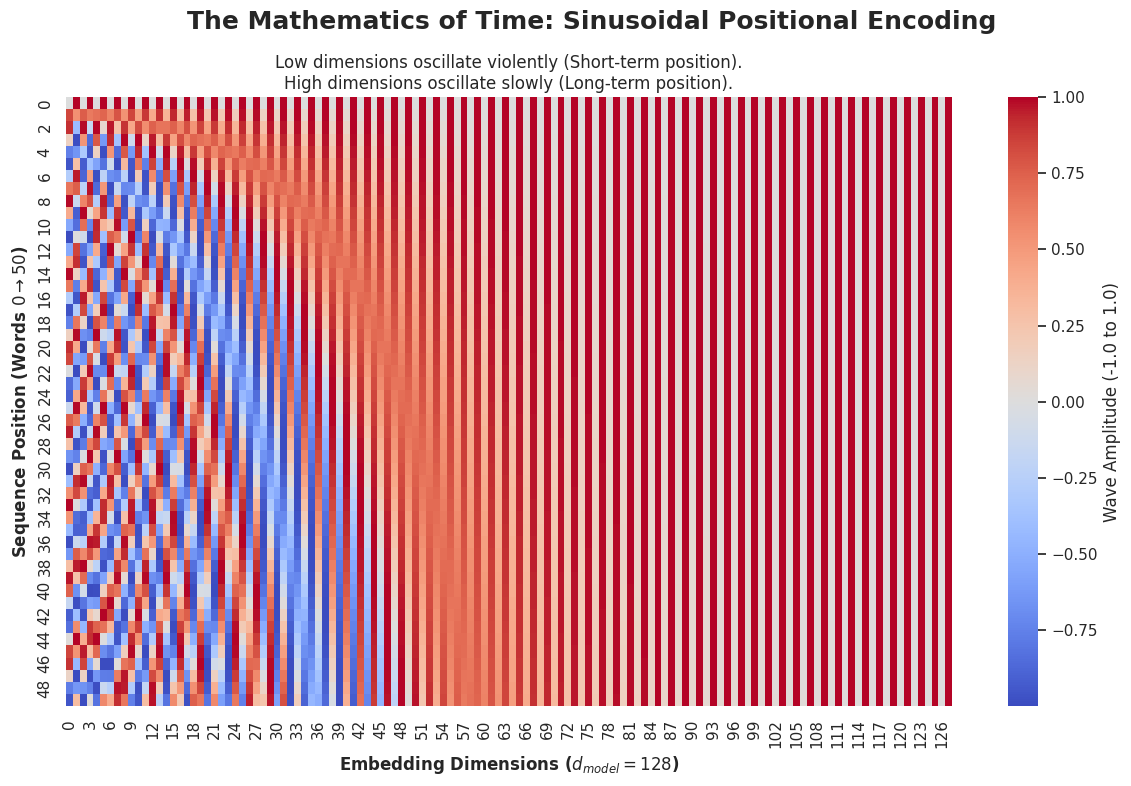


--- 💡 Architectural Insight ---
Look at the Heatmap. The far-left columns (low dimensions) flash from red to blue incredibly fast, creating a unique micro-fingerprint for every single word position. The far-right columns (high dimensions) change very slowly, staying mostly blue at the top and red at the bottom, creating a macro-fingerprint for where the word is located in the grand scope of the entire paragraph. By adding these waves to our word vectors, the network inherently 'feels' the geometric distance between words without ever needing a recurrent loop!


In [2]:
# 1. The Mathematics of Positional Encoding
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=100):
        super().__init__()
        
        # Create a massive matrix of zeros: [max_len, d_model]
        pe = torch.zeros(max_len, d_model)
        
        # Create a column vector of positions: [[0], [1], [2], ..., [max_len-1]]
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        
        # Calculate the divisor term: 10000^(2i / d_model)
        # We use exponential and log math for numerical stability!
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        
        # Apply Sine to even indices (0, 2, 4...)
        pe[:, 0::2] = torch.sin(position * div_term)
        
        # Apply Cosine to odd indices (1, 3, 5...)
        pe[:, 1::2] = torch.cos(position * div_term)
        
        # Add a batch dimension: [1, max_len, d_model]
        pe = pe.unsqueeze(0)
        
        # Register as a buffer (It is a fixed mathematical constant, NOT a learnable weight)
        self.register_buffer('pe', pe)

    def forward(self, x):
        # x shape: [Batch, Seq_Len, d_model]
        # We slice the PE matrix to exactly match the length of the input sequence and ADD it.
        x = x + self.pe[:, :x.size(1), :]
        return x

# 2. Architecting the Full Transformer Encoder Block
class TransformerEncoderBlock(nn.Module):
    def __init__(self, d_model=512, num_heads=8, dim_feedforward=2048):
        super().__init__()
        # The Multi-Head Attention Mechanism
        self.self_attn = nn.MultiheadAttention(embed_dim=d_model, num_heads=num_heads, batch_first=True)
        
        # The Feed-Forward Network
        self.linear1 = nn.Linear(d_model, dim_feedforward)
        self.dropout = nn.Dropout(0.1)
        self.linear2 = nn.Linear(dim_feedforward, d_model)
        self.activation = nn.ReLU()
        
        # The Stabilizers (Add & Norm)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout1 = nn.Dropout(0.1)
        self.dropout2 = nn.Dropout(0.1)

    def forward(self, src):
        # Phase 1: Multi-Head Self Attention + Residual + Norm
        # (PyTorch MHA returns the output and the attention weights, we just want the output [0])
        attn_output = self.self_attn(query=src, key=src, value=src)[0]
        src = src + self.dropout1(attn_output) # The Add
        src = self.norm1(src)                  # The Norm
        
        # Phase 2: Feed-Forward Network + Residual + Norm
        ffn_output = self.linear2(self.dropout(self.activation(self.linear1(src))))
        src = src + self.dropout2(ffn_output)  # The Add
        src = self.norm2(src)                  # The Norm
        return src

# 3. Visualizing the Positional Encoding Geometry
D_MODEL = 128
MAX_LEN = 50

print("--- 🔬 Generating Trigonometric Positional Encodings ---")
pe_layer = PositionalEncoding(d_model=D_MODEL, max_len=MAX_LEN)

# Extract the fixed PE matrix [50, 128]
pe_matrix = pe_layer.pe.squeeze(0).numpy()

fig, ax = plt.subplots(figsize=(12, 8))
fig.suptitle("The Mathematics of Time: Sinusoidal Positional Encoding", fontsize=18, fontweight='bold')

sns.heatmap(pe_matrix, cmap="coolwarm", cbar_kws={'label': 'Wave Amplitude (-1.0 to 1.0)'}, ax=ax)

ax.set_xlabel("Embedding Dimensions ($d_{model} = 128$)", fontsize=12, fontweight='bold')
ax.set_ylabel("Sequence Position (Words $0 \\rightarrow 50$)", fontsize=12, fontweight='bold')
ax.set_title("Low dimensions oscillate violently (Short-term position).\nHigh dimensions oscillate slowly (Long-term position).", fontsize=12)

plt.tight_layout()
plt.show()

print("\n--- 💡 Architectural Insight ---")
print("Look at the Heatmap. The far-left columns (low dimensions) flash from red to blue incredibly fast, creating a unique micro-fingerprint for every single word position. The far-right columns (high dimensions) change very slowly, staying mostly blue at the top and red at the bottom, creating a macro-fingerprint for where the word is located in the grand scope of the entire paragraph. By adding these waves to our word vectors, the network inherently 'feels' the geometric distance between words without ever needing a recurrent loop!")

## Real-World Use Case or Analogy:

Think of the entire Transformer Block like **A massive Corporate Boardroom meeting**:

* **The Input Embeddings**: The 50 employees walking into the room.
* **Positional Encoding (The Seating Chart)**: Because everyone talks at the exact same time, it's total chaos. You tape a specific seat number to everyone's chest. Even though they are talking over each other, you know exactly who sits next to who based on their number.
* **Multi-Head Attention (The Sub-Committees)**: The 50 employees split their brains into 8 different sub-committees. Head 1 discusses budget. Head 2 discusses marketing. Head 3 discusses HR. They talk to everyone in the room simultaneously and gather massive amounts of context.
* **The Residual Connection (The Meeting Minutes)**: After the chaotic sub-committee shouting match, someone says, *"Wait, let's not forget what our original jobs were."* They add the original employee's baseline knowledge back into their new contextual knowledge.
* **The Feed-Forward Network (Independent Desk Work)**: After the boardroom meeting adjourns, all 50 employees go back to their individual, isolated desks. They process the new information they just learned (The non-linear MLP expansion) to finalize their thoughts.
* **The Next Layer**: They walk into the *next* boardroom meeting (Layer 2) vastly smarter than before.